# **1. Import Library**

In [234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from xgboost import XGBRegressor

from statsmodels.graphics.tsaplots import plot_pacf

# **2. Data Loading**

In [235]:
path = '../data/processed/processed_waste_dataset.csv'

df = pd.read_csv(path)

df.head()

,tanggal,berat_kg,volume_m3,log_volume_m3,is_monday
0,2026-04-18,17.68,0.191651,0.175340,0
1,2026-04-20,36.09,0.594873,0.466794,1
2,2026-04-21,67.05,0.487233,0.396918,0
3,2026-04-22,60.20,0.546106,0.435740,0
4,2026-04-23,18.48,0.293353,0.257238,0


# **3. Feature Engineering**

In [236]:
df = df.sort_values(by="tanggal").reset_index(drop=True)

df["lag_1d"] = df["log_volume_m3"].shift(1)
df["lag_3d"] = df["log_volume_m3"].shift(3)

df["rolling_3d"] = (
    df["log_volume_m3"].shift(1).rolling(window=3).mean()
)

df_model = df.dropna().reset_index(drop=True)

print(f"Jumlah baris setelah windowing: {len(df_model)} baris (Sesuai Rencana)")
df_model[["tanggal", "is_monday", "lag_1d", "lag_3d", "rolling_3d", "log_volume_m3"]].head()

Jumlah baris setelah windowing: 43 baris (Sesuai Rencana)


,tanggal,is_monday,lag_1d,lag_3d,rolling_3d,log_volume_m3
0,2026-04-22,0,0.396918,0.175340,0.346351,0.435740
1,2026-04-23,0,0.435740,0.466794,0.433150,0.257238
2,2026-04-24,0,0.257238,0.396918,0.363298,0.180170
3,2026-04-25,0,0.180170,0.435740,0.291049,0.530455
4,2026-04-27,1,0.530455,0.257238,0.322621,0.568016


/tmp/ipykernel_13677/1128145342.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="nama_hari", y="volume_m3", order=order_hari, palette="Set2", ax=axes[1], fliersize=0)


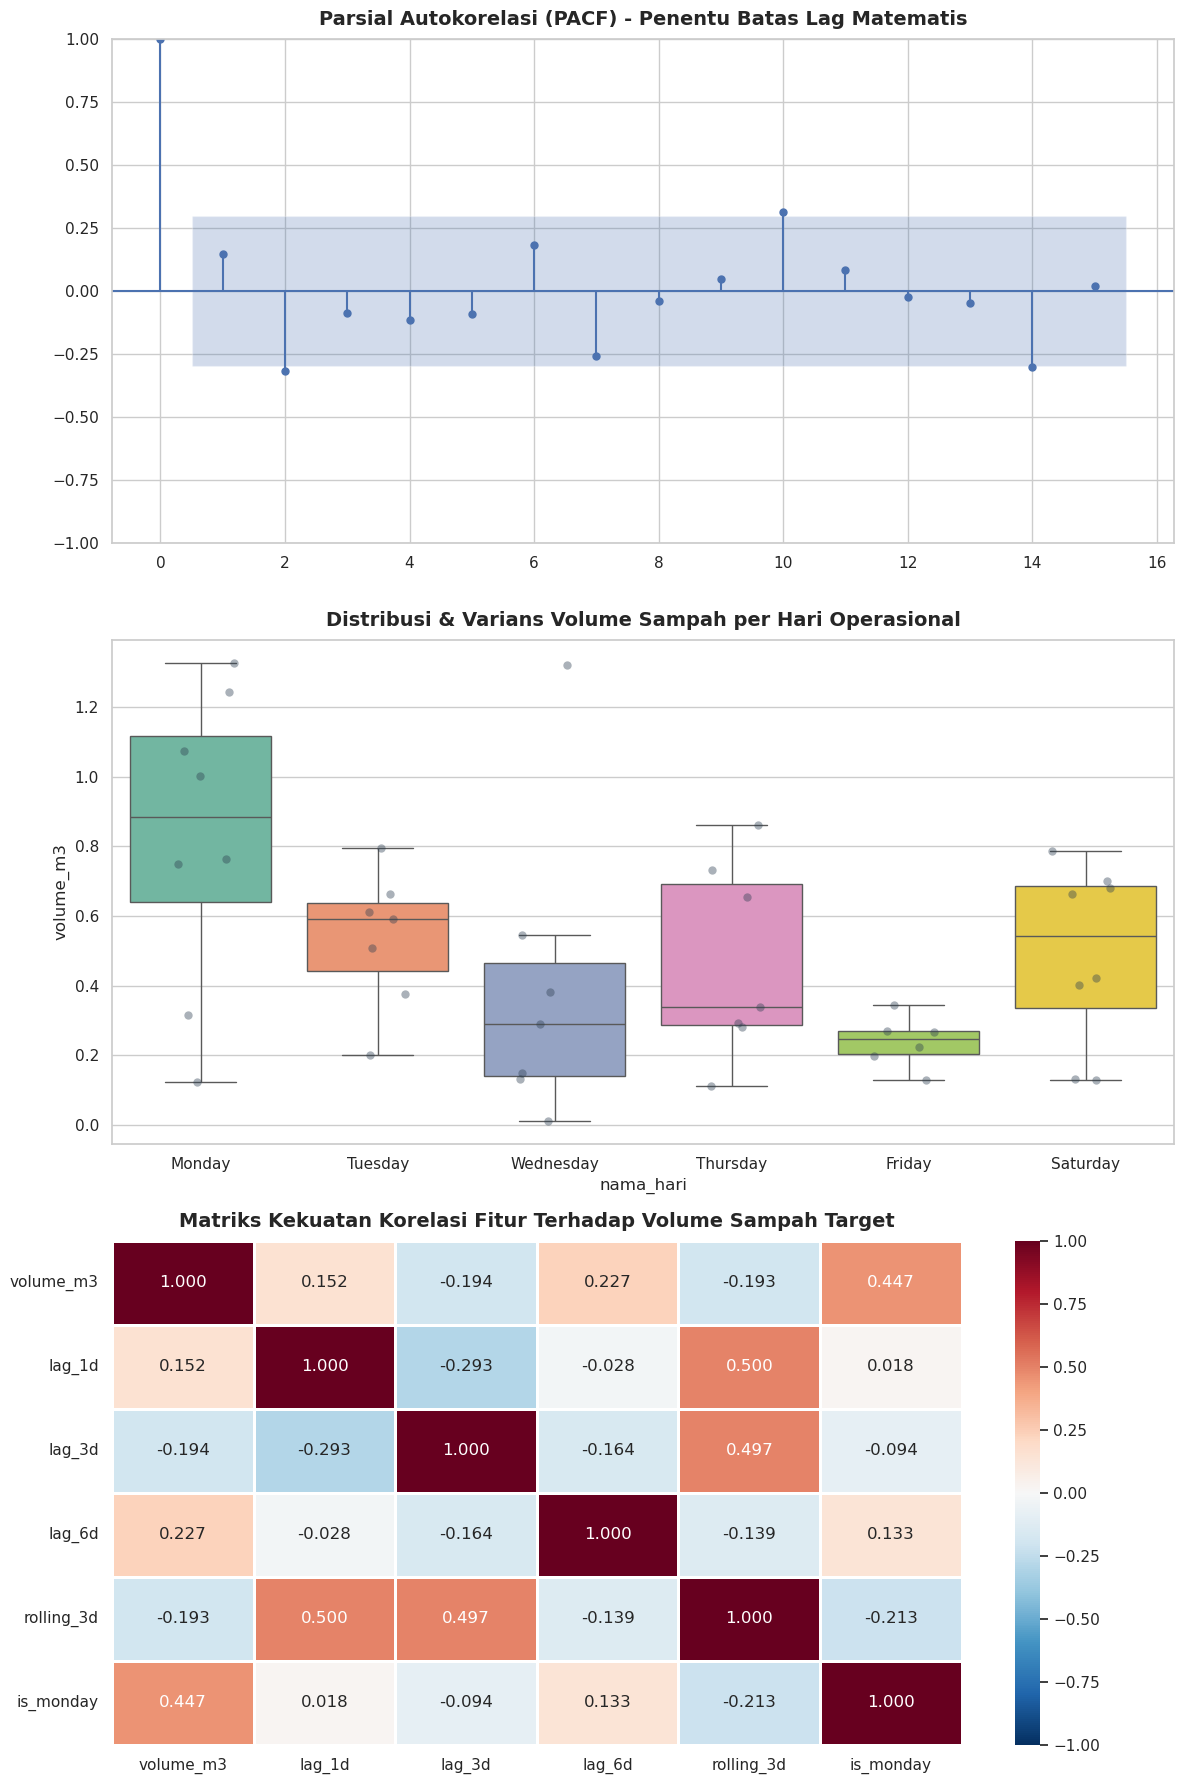

In [237]:
df_model["tanggal"] = pd.to_datetime(df_model["tanggal"])
df_model = df_model.sort_values("tanggal").reset_index(drop=True)

df_model["nama_hari"] = df_model["tanggal"].dt.day_name()
order_hari = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

df_model["lag_6d"] = df_model["volume_m3"].shift(6)

fig, axes = plt.subplots(3, 1, figsize=(12, 18))
sns.set_theme(style="whitegrid")

plot_pacf(df_model["volume_m3"].dropna(), lags=15, ax=axes[0], method="ywm")
axes[0].set_title("Parsial Autokorelasi (PACF) - Penentu Batas Lag Matematis", fontsize=14, fontweight="bold", pad=10)

sns.boxplot(data=df_model, x="nama_hari", y="volume_m3", order=order_hari, palette="Set2", ax=axes[1], fliersize=0)
sns.stripplot(data=df_model, x="nama_hari", y="volume_m3", order=order_hari, color="#2c3e50", alpha=0.4, size=6, jitter=0.2, ax=axes[1])
axes[1].set_title("Distribusi & Varians Volume Sampah per Hari Operasional", fontsize=14, fontweight="bold", pad=10)

fitur_analisis = ["volume_m3", "lag_1d", "lag_3d", "lag_6d", "rolling_3d", "is_monday"]
corr_matrix = df_model[fitur_analisis].corr()
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", vmin=-1, vmax=1, fmt=".3f", linewidths=0.8, ax=axes[2])
axes[2].set_title("Matriks Kekuatan Korelasi Fitur Terhadap Volume Sampah Target", fontsize=14, fontweight="bold", pad=10)

plt.tight_layout()
plt.show()

In [238]:
df_model["is_saturday"] = (df_model["nama_hari"] == "Saturday").astype(int)
df_model["is_low_traffic"] = df_model["nama_hari"].isin(["Wednesday", "Friday"]).astype(int)
df_model["is_monday"] = (df_model["nama_hari"] == "Monday").astype(int)
df_model["is_tuesday"] = (df_model["nama_hari"] == "Tuesday").astype(int)

df_model["lag_1d"] = df_model["volume_m3"].shift(1)
df_model["lag_6d"] = df_model["volume_m3"].shift(6)  
df_model["lag_9d"] = df_model["volume_m3"].shift(9)

df_model["rolling_3d"] = df_model["lag_1d"].rolling(window=3).mean()
df_model["ewm_3d"] = df_model["volume_m3"].shift(1).ewm(span=3).mean()

df_model["monday_weekend_interaction"] = df_model["is_monday"] * df_model["lag_1d"]

df_model["tuesday_monday_lag_interaction"] = df_model["is_tuesday"] * df_model["lag_1d"]

df_model["volume_acceleration"] = df_model["lag_1d"] / (df_model["rolling_3d"] + 1e-5)

df_model["lag_10d"] = df_model["volume_m3"].shift(10)

df_model["is_wednesday"] = (df_model["nama_hari"] == "Wednesday").astype(int)
df_model["is_friday"] = (df_model["nama_hari"] == "Friday").astype(int)

df_model["rolling_std_3d"] = df_model["lag_1d"].rolling(window=3).std()

df_model_final = df_model.dropna().reset_index(drop=True)

print(f"Data bersih siap pakai: {df_model_final.shape[0]} baris (setelah drop NaN akibat lag).")

Data bersih siap pakai: 33 baris (setelah drop NaN akibat lag).


/tmp/ipykernel_13677/4261074877.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model_final, x="nama_hari", y="volume_m3", order=order_hari, palette="Set2", ax=axes[1], fliersize=0)


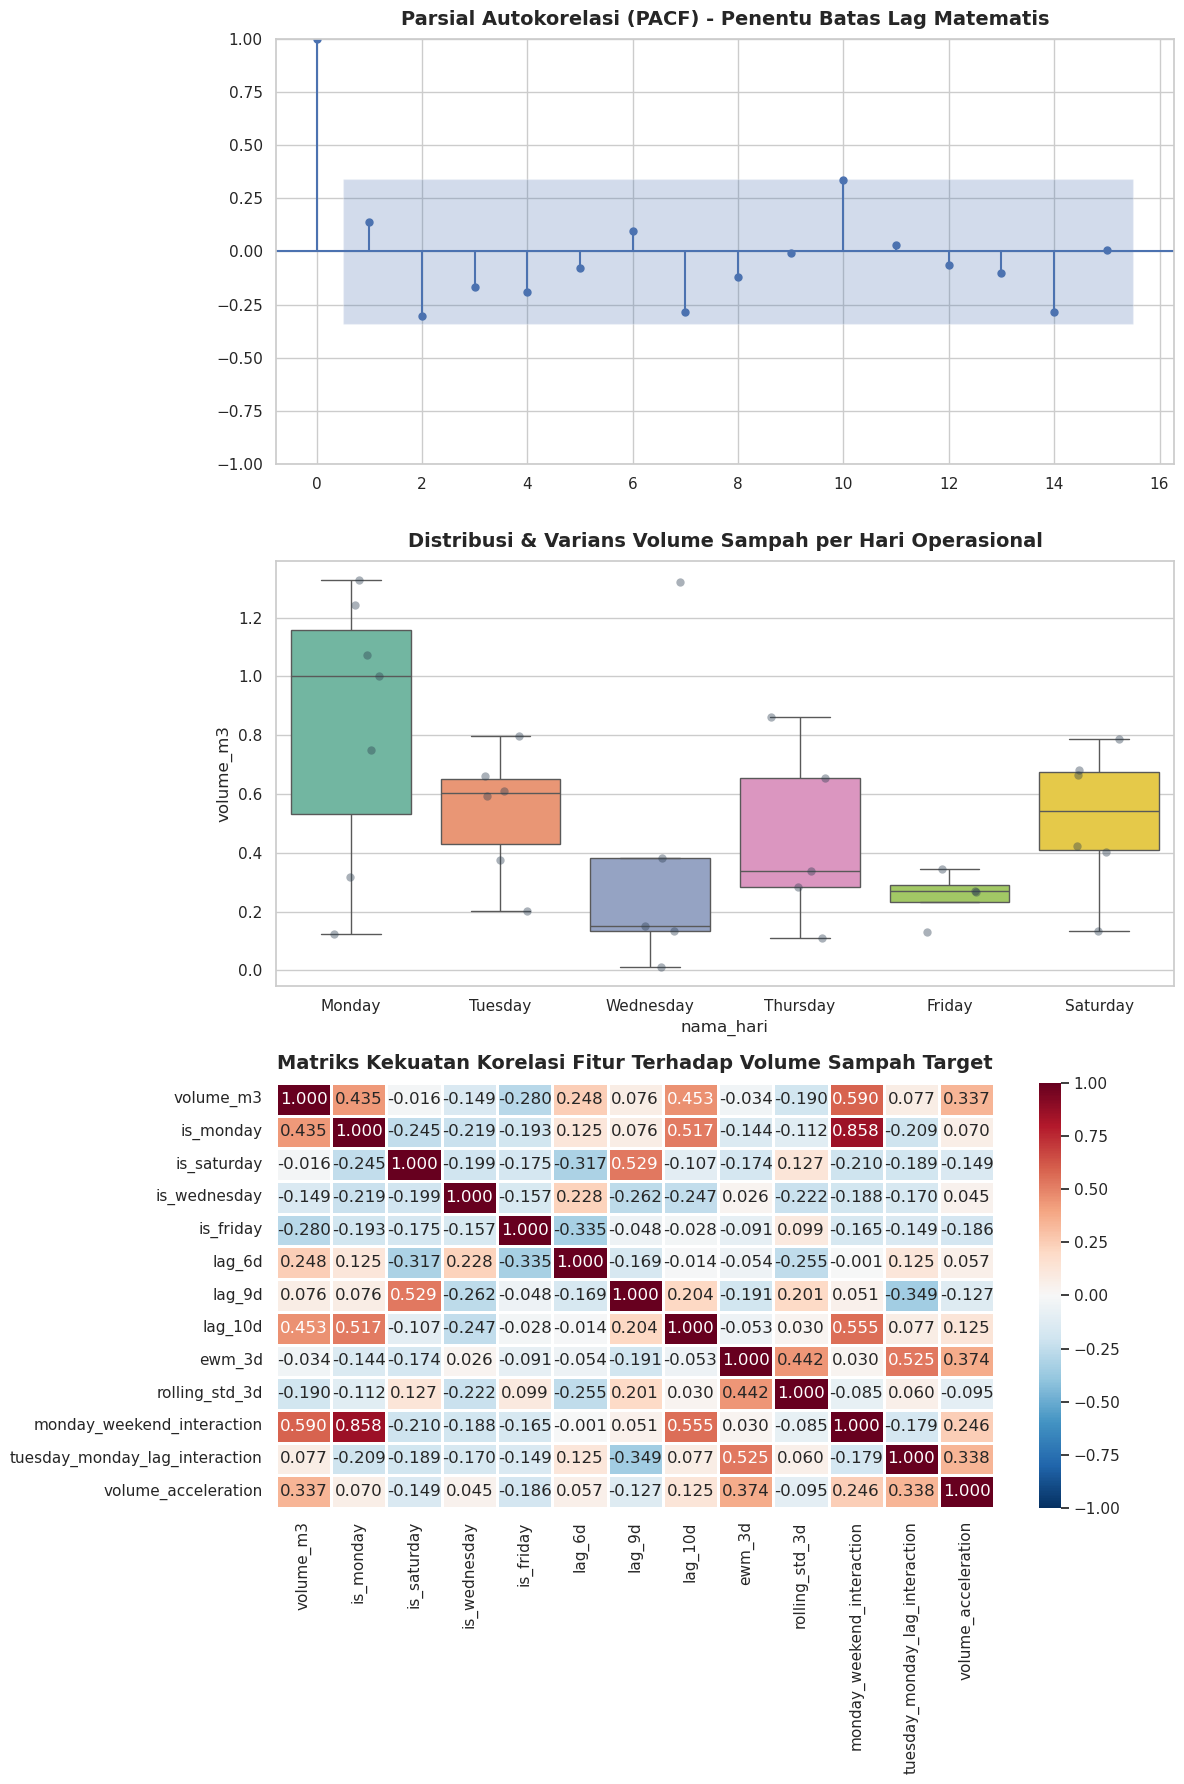

In [239]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

plot_pacf(df_model_final["volume_m3"].dropna(), lags=15, ax=axes[0], method="ywm")
axes[0].set_title("Parsial Autokorelasi (PACF) - Penentu Batas Lag Matematis", fontsize=14, fontweight="bold", pad=10)

sns.boxplot(data=df_model_final, x="nama_hari", y="volume_m3", order=order_hari, palette="Set2", ax=axes[1], fliersize=0)
sns.stripplot(data=df_model_final, x="nama_hari", y="volume_m3", order=order_hari, color="#2c3e50", alpha=0.4, size=6, jitter=0.2, ax=axes[1])
axes[1].set_title("Distribusi & Varians Volume Sampah per Hari Operasional", fontsize=14, fontweight="bold", pad=10)

fitur_analisis = [
    "volume_m3", "is_monday", "is_saturday", "is_wednesday", "is_friday", 
    "lag_6d", "lag_9d", "lag_10d", "ewm_3d", "rolling_std_3d",
    "monday_weekend_interaction", "tuesday_monday_lag_interaction", "volume_acceleration"
]

corr_matrix = df_model_final[fitur_analisis].corr()
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", vmin=-1, vmax=1, fmt=".3f", linewidths=0.8, ax=axes[2])
axes[2].set_title("Matriks Kekuatan Korelasi Fitur Terhadap Volume Sampah Target", fontsize=14, fontweight="bold", pad=10)

plt.tight_layout()
plt.show()

# **4. Data Splitting**

# Dasar Pertimbangan Seleksi Fitur (*Feature Selection*)

Dari banyaknya fitur yang dihasilkan pada tahap *feature engineering*, dipilih empat fitur utama sebagai prediktor akhir untuk proses pelatihan model. Pembatasan jumlah fitur ini didasarkan pada dua pertimbangan ilmiah utama sebagai berikut.

## 1. Menghindari Overfitting

Ukuran dataset yang relatif kecil membuat model menjadi sensitif terhadap tingginya dimensi data. Penggunaan terlalu banyak fitur berpotensi menyebabkan model mempelajari *noise* dan pola yang tidak relevan, sehingga performa pada data pelatihan meningkat tetapi kemampuan generalisasi terhadap data baru menurun.

Oleh karena itu, pembatasan jumlah prediktor menjadi empat fitur terbaik memberikan *degree of freedom* yang lebih ideal sehingga model dapat menangkap pola utama data tanpa mengalami *overfitting*.

## 2. Eliminasi Multikolinieritas

Berdasarkan analisis Matriks Korelasi Pearson, ditemukan beberapa fitur yang memiliki korelasi sangat tinggi antar variabel independen. Sebagai contoh, fitur `is_monday` memiliki korelasi sebesar **0,858** terhadap fitur `monday_weekend_interaction`.

Kondisi tersebut menunjukkan adanya duplikasi informasi yang dapat menimbulkan masalah multikolinieritas, terutama pada model berbasis regresi dan model linier lainnya. Oleh karena itu, fitur-fitur yang membawa informasi serupa dieliminasi untuk menjaga stabilitas model dan meningkatkan interpretabilitas hasil.

---

# Analisis Pemilihan Fitur

## 1. `monday_weekend_interaction`

**Korelasi Pearson terhadap target:** **+0,590**

### Logika Data Science

Fitur ini memiliki nilai korelasi positif tertinggi terhadap variabel target volume sampah. Variabel dibentuk melalui interaksi antara indikator hari Senin (`is_monday`) dengan volume sampah hari sebelumnya (`lag_1d`).

Fitur interaksi ini memungkinkan model menangkap pengaruh gabungan antara faktor kalender dan kondisi historis volume sampah.

### Karakteristik Operasional

Hari Senin secara konsisten menjadi periode dengan volume sampah tertinggi akibat akumulasi aktivitas masyarakat selama akhir pekan. Dengan menggabungkan informasi hari Senin dan volume aktual hari sebelumnya, fitur ini menjadi indikator yang sangat kuat untuk mengantisipasi lonjakan volume sampah pasca-akhir pekan.

Selain itu, keberadaan fitur ini juga menggantikan fungsi `is_monday` sehingga membantu mengurangi risiko multikolinieritas.

---

## 2. `lag_10d`

**Korelasi Pearson terhadap target:** **+0,453**

### Logika Data Science

Di antara seluruh fitur historis (*historical lag feature*), `lag_10d` menunjukkan hubungan linear positif paling kuat terhadap volume sampah saat ini.

Fitur ini merepresentasikan volume sampah yang tercatat sepuluh hari sebelumnya.

### Karakteristik Operasional

Pola timbulan sampah pada kawasan residensial tidak selalu mengikuti siklus mingguan (*weekly cycle*) yang kaku. Aktivitas pengangkutan dan pengelolaan sampah sering kali dipengaruhi oleh jadwal operasional, kebijakan pengelolaan, maupun faktor eksternal lainnya yang membentuk pola periodik lebih panjang.

Fitur `lag_10d` berfungsi sebagai *long-term memory anchor* yang memungkinkan model menangkap pola berulang tersebut dan memanfaatkan informasi historis jangka menengah dalam proses prediksi.

---

## 3. `volume_acceleration`

**Korelasi Pearson terhadap target:** **+0,337**

### Logika Data Science

Fitur ini dihitung sebagai rasio antara volume sampah hari sebelumnya (`lag_1d`) dan rata-rata bergerak tiga hari sebelumnya (`rolling_3d`).

Fitur ini merepresentasikan momentum atau percepatan perubahan volume sampah terhadap tren jangka pendeknya.

### Karakteristik Operasional

Nilai fitur yang lebih besar dari satu menunjukkan bahwa volume sampah pada hari sebelumnya berada di atas rata-rata normal beberapa hari terakhir.

Kondisi tersebut mengindikasikan adanya fase peningkatan timbulan sampah (*upward momentum*), sedangkan nilai yang lebih kecil dari satu menunjukkan perlambatan aktivitas.

Informasi momentum seperti ini sangat bermanfaat terutama bagi model berbasis pohon keputusan (*tree-based models*) karena membantu membedakan kondisi ketika volume sampah sedang meningkat, stabil, atau mulai menurun.

---

## 4. `is_friday`

**Korelasi Pearson terhadap target:** **−0,280**

### Logika Data Science

Fitur `is_friday` dipilih karena memiliki korelasi negatif paling signifikan dibandingkan fitur biner hari lainnya.

Fitur ini berfungsi sebagai indikator kalender yang menandai apakah suatu observasi terjadi pada hari Jumat.

### Karakteristik Operasional

Berdasarkan hasil analisis pola harian, hari Jumat cenderung menjadi titik terendah (*baseline minimum*) volume sampah sebelum memasuki siklus akhir pekan.

Kehadiran fitur ini memberikan sinyal penurunan volume kepada model sehingga prediksi dapat disesuaikan secara lebih realistis pada hari-hari dengan aktivitas pembuangan sampah yang relatif rendah.

Dengan demikian, `is_friday` berperan sebagai mekanisme penyeimbang yang membantu mengurangi risiko *over-estimation* pada hasil prediksi.

---

# Kesimpulan

Keempat fitur terpilih mewakili aspek yang saling melengkapi dalam menjelaskan dinamika volume sampah, yaitu:

| Fitur                        | Peran Utama                                                  |
| ---------------------------- | ------------------------------------------------------------ |
| `monday_weekend_interaction` | Menangkap lonjakan volume pasca-akhir pekan                  |
| `lag_10d`                    | Merepresentasikan pola historis jangka menengah              |
| `volume_acceleration`        | Mengukur momentum perubahan volume sampah                    |
| `is_friday`                  | Menangkap penurunan volume pada hari dengan aktivitas rendah |

Kombinasi keempat fitur tersebut dipilih karena mampu memberikan keseimbangan antara kekuatan prediktif, interpretabilitas model, serta minimisasi risiko *overfitting* dan multikolinieritas.


In [240]:
fitur = [
    "monday_weekend_interaction",  
    "lag_10d",                     
    "volume_acceleration",       
    "is_friday",                                   
]

X = df_model_final[fitur]
y_log = df_model_final["log_volume_m3"]  
y_orig = df_model_final["volume_m3"]     

test_size = 6
split_idx = len(df_model_final) - test_size

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_log, y_test_log = y_log.iloc[:split_idx], y_log.iloc[split_idx:]

y_test_orig = y_orig.iloc[split_idx:]
dates_test = df_model_final["tanggal"].iloc[split_idx:]

print("--- Pembagian Dimensi Data (Siklus 1 Minggu Kerja) ---")
print(f"X_train: {X_train.shape} | y_train_log: {y_train_log.shape} -> (Data Training)")
print(f"X_test : {X_test.shape}  | y_test_orig : {y_test_orig.shape} -> (Data Test: 1 Siklus Penuh)")
print(f"Fitur aktif yang digunakan model: {list(X.columns)}")

--- Pembagian Dimensi Data (Siklus 1 Minggu Kerja) ---
X_train: (27, 4) | y_train_log: (27,) -> (Data Training)
X_test : (6, 4)  | y_test_orig : (6,) -> (Data Test: 1 Siklus Penuh)
Fitur aktif yang digunakan model: ['monday_weekend_interaction', 'lag_10d', 'volume_acceleration', 'is_friday']


# **5. Modelling**

In [241]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=0.1),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100, random_state=42
    ),
    "Extra Trees Regressor": ExtraTreesRegressor(
        n_estimators=100, random_state=42
    ),
    "XGBoost Regressor": XGBRegressor(
        n_estimators=100, learning_rate=0.05, random_state=42
    ),
}

results = []

y_pred_naive_orig = np.expm1(X_test["monday_weekend_interaction"])

results.append(
    {
        "Model": "Baseline (Naive Predictor)",
        "MAE (m³)": mean_absolute_error(y_test_orig, y_pred_naive_orig),
        "MSE": mean_squared_error(y_test_orig, y_pred_naive_orig),
        "RMSE (m³)": np.sqrt(mean_squared_error(y_test_orig, y_pred_naive_orig)),
        "MAPE (%)": mean_absolute_percentage_error(
            y_test_orig, y_pred_naive_orig
        )
        * 100,
        "R² Score": r2_score(y_test_orig, y_pred_naive_orig),
    }
)

for name, model in models.items():
    model.fit(X_train, y_train_log)

    y_pred_log = model.predict(X_test)

    y_pred_orig = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_test_orig, y_pred_orig)
    mse = mean_squared_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test_orig, y_pred_orig) * 100
    r2 = r2_score(y_test_orig, y_pred_orig)

    
    results.append(
        {
            "Model": name,
            "MAE (m³)": mae,
            "MSE": mse,
            "RMSE (m³)": rmse,
            "MAPE (%)": mape,
            "R² Score": r2,
        }
    )

print("Proses pelatihan dan evaluasi seluruh model selesai!")

Proses pelatihan dan evaluasi seluruh model selesai!


# **6. Model Evaluation**

In [242]:
df_results = pd.DataFrame(results)

df_results = df_results.sort_values(by="MAE (m³)", ascending=True).reset_index(
    drop=True
)

display(df_results.style.highlight_min(subset=["MAE (m³)", "RMSE (m³)", "MAPE (%)"], color="black"))

,Model,MAE (m³),MSE,RMSE (m³),MAPE (%),R² Score
0,XGBoost Regressor,0.120186,0.025763,0.160509,30.798525,0.777303
1,Random Forest Regressor,0.121167,0.022589,0.150295,29.285103,0.804742
2,Linear Regression,0.131568,0.030949,0.175924,26.749633,0.732474
3,Ridge Regression,0.133513,0.032310,0.179748,27.006277,0.720715
4,Extra Trees Regressor,0.137126,0.027256,0.165093,29.683861,0.764399
5,Baseline (Naive Predictor),0.409525,0.193136,0.439473,93.342717,-0.669479


## Visualisasi

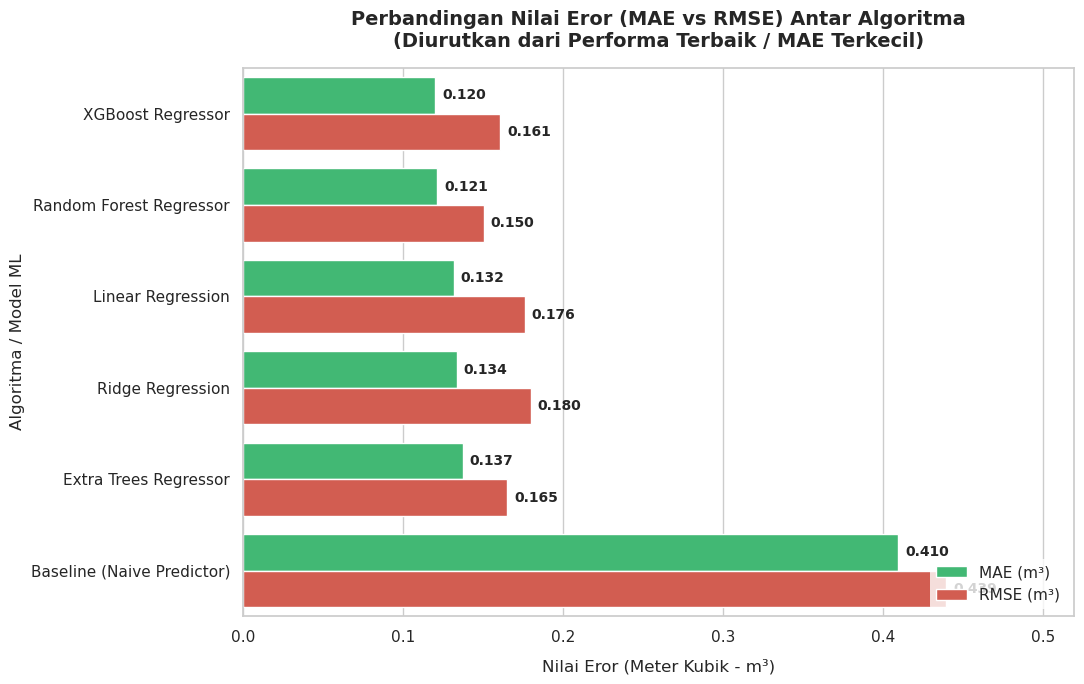

In [243]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 7))

df_sorted = df_results.sort_values(by="MAE (m³)", ascending=True)

df_melted = df_sorted.melt(
    id_vars="Model",
    value_vars=["MAE (m³)", "RMSE (m³)"],
    var_name="Metrik Evaluasi",
    value_name="Nilai Eror (m³)"
)

ax = sns.barplot(
    data=df_melted,
    y="Model",
    x="Nilai Eror (m³)",
    hue="Metrik Evaluasi",
    palette=["#2ecc71", "#e74c3c"]  
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=5, fontsize=10, fontweight="semibold")

plt.title(
    "Perbandingan Nilai Eror (MAE vs RMSE) Antar Algoritma\n(Diurutkan dari Performa Terbaik / MAE Terkecil)",
    fontsize=14,
    fontweight="bold",
    pad=15
)
plt.xlabel("Nilai Eror (Meter Kubik - m³)", fontsize=12, labelpad=10)
plt.ylabel("Algoritma / Model ML", fontsize=12)
plt.xlim(0, df_results["RMSE (m³)"].max() + 0.08) 
plt.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout()

plt.show()

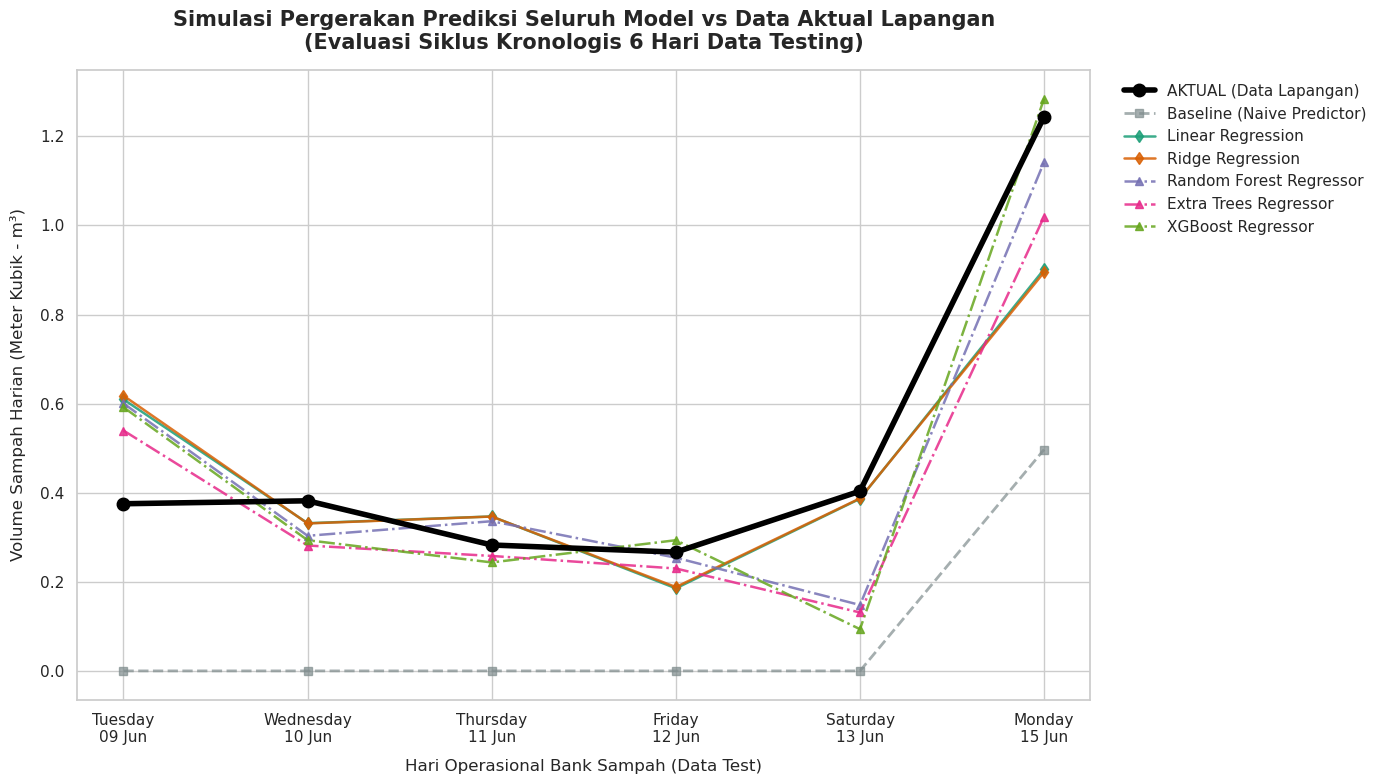

In [244]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

dates_test_dt = pd.to_datetime(dates_test)

x_labels = dates_test_dt.dt.strftime("%A\n%d %b")

plt.plot(
    x_labels,
    y_test_orig,
    label="AKTUAL (Data Lapangan)",
    color="#000000",
    linewidth=4.0,
    marker="o",
    markersize=9,
    zorder=10,  
)

y_pred_naive_orig = np.expm1(X_test["monday_weekend_interaction"])
plt.plot(
    x_labels,
    y_pred_naive_orig,
    label="Baseline (Naive Predictor)",
    color="#7f8c8d",
    linestyle="--",
    linewidth=2.0,
    marker="s",
    alpha=0.7,
)

colors = sns.color_palette("Dark2", len(models))

for (name, model), color in zip(models.items(), colors):
    model.fit(X_train, y_train_log)
    y_pred_log = model.predict(X_test)
    y_pred_orig = np.expm1(y_pred_log)

    if "Regressor" in name:  
        linestyle = "-."
        marker = "^"
    elif "Polynomial" in name:  
        linestyle = ":"
        marker = "x"
    else:  
        linestyle = "-"
        marker = "d"

    plt.plot(
        x_labels,
        y_pred_orig,
        label=name,
        color=color,
        linestyle=linestyle,
        linewidth=1.8,
        marker=marker,
        alpha=0.85,
    )

plt.title(
    "Simulasi Pergerakan Prediksi Seluruh Model vs Data Aktual Lapangan\n(Evaluasi Siklus Kronologis 6 Hari Data Testing)",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Hari Operasional Bank Sampah (Data Test)", fontsize=12, labelpad=10)
plt.ylabel("Volume Sampah Harian (Meter Kubik - m³)", fontsize=12, labelpad=10)

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    facecolor="white",
    edgecolor="none",
    fontsize=11,
)

plt.tight_layout()
plt.show()

In [245]:
y_train_orig = np.expm1(y_train_log)

results = []

y_pred_naive_orig = np.expm1(X_test["monday_weekend_interaction"])
results.append(
    {
        "Model": "Baseline (Naive Predictor)",
        "Train MAE": np.nan,
        "Test MAE": mean_absolute_error(y_test_orig, y_pred_naive_orig),
        "Train R² Score": np.nan,
        "Test R² Score": r2_score(y_test_orig, y_pred_naive_orig),
        "Train RMSE": np.nan,
        "Test RMSE": np.sqrt(mean_squared_error(y_test_orig, y_pred_naive_orig)),
    }
)

for name, model in models.items():
    model.fit(X_train, y_train_log)

    y_train_pred_log = model.predict(X_train)
    y_train_pred_orig = np.expm1(y_train_pred_log)
    
    mae_train = mean_absolute_error(y_train_orig, y_train_pred_orig)
    rmse_train = np.sqrt(mean_squared_error(y_train_orig, y_train_pred_orig))
    r2_train = r2_score(y_train_orig, y_train_pred_orig)

    y_test_pred_log = model.predict(X_test)
    y_test_pred_orig = np.expm1(y_test_pred_log)
    
    mae_test = mean_absolute_error(y_test_orig, y_test_orig) if 'y_test_orig' in locals() and name == "Baseline (Naive Predictor)" else mean_absolute_error(y_test_orig, y_test_pred_orig)
    rmse_test = np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig))
    r2_test = r2_score(y_test_orig, y_test_pred_orig)

    results.append(
        {
            "Model": name,
            "Train MAE": mae_train,
            "Test MAE": mae_test,
            "Train R² Score": r2_train,
            "Test R² Score": r2_test,
            "Train RMSE": rmse_train,
            "Test RMSE": rmse_test,
        }
    )

df_results = pd.DataFrame(results)
print("Proses pelatihan dan evaluasi seluruh model selesai!")
display(df_results)

Proses pelatihan dan evaluasi seluruh model selesai!


,Model,Train MAE,Test MAE,Train R² Score,Test R² Score,Train RMSE,Test RMSE
0,Baseline (Naive Predictor),NaN,0.409525,NaN,-0.669479,NaN,0.439473
1,Linear Regression,2.401928e-01,0.131568,0.375000,0.732474,2.920874e-01,0.175924
2,Ridge Regression,2.398825e-01,0.133513,0.374432,0.720715,2.922199e-01,0.179748
3,Random Forest Regressor,1.045264e-01,0.121167,0.882298,0.804742,1.267549e-01,0.150295
4,Extra Trees Regressor,7.573032e-16,0.137126,1.000000,0.764399,1.032184e-15,0.165093
5,XGBoost Regressor,1.284610e-02,0.120186,0.997705,0.777303,1.769905e-02,0.160509


# Dasar Pertimbangan Pemilihan Model Terbaik (*Model Selection*)

Penentuan model terbaik untuk memprediksi volume sampah tidak semata-mata didasarkan pada nilai *error* terkecil atau nilai $R^2$ tertinggi pada data pengujian (*test set*). Mengingat ukuran dataset yang relatif terbatas, proses evaluasi juga mempertimbangkan kemampuan generalisasi model melalui analisis *overfitting* dan *underfitting*.

Diagnosis dilakukan dengan membandingkan performa model pada data pelatihan (*train set*) dan data pengujian (*test set*) secara berdampingan. Pendekatan ini memungkinkan identifikasi apakah model benar-benar mempelajari pola data yang relevan atau hanya menghafal data pelatihan.

Berdasarkan hasil eksperimen pada skenario prediksi siklus operasional enam hari, model-model yang diuji dapat dikelompokkan ke dalam tiga karakteristik utama.

---

# 1. Kelompok Overfitting Ekstrem

**Model:** Extra Trees Regressor dan XGBoost Regressor

## Karakteristik

Model berbasis *ensemble learning* yang agresif, seperti Extra Trees dan XGBoost, menunjukkan gejala *memorization* atau kecenderungan menghafal data pelatihan secara berlebihan.

## Analisis

Extra Trees menghasilkan nilai **Train $R^2 = 1.0000$** dengan **Train MAE mendekati nol ($7.57 \times 10^{-16}$)**, yang menunjukkan kemampuan hampir sempurna dalam mereproduksi data pelatihan.

Fenomena serupa juga terlihat pada XGBoost dengan **Train $R^2 = 0.9977$**. Namun, performa yang sangat tinggi pada data pelatihan tidak diikuti oleh peningkatan yang proporsional pada data pengujian, di mana nilai **Test $R^2$ hanya berada pada kisaran 0,76–0,77**.

Perbedaan performa yang signifikan antara data pelatihan dan data pengujian menunjukkan bahwa kedua model terlalu sensitif terhadap variasi dan *noise* pada dataset yang berukuran kecil. Akibatnya, model berisiko mengalami penurunan performa ketika digunakan untuk memprediksi data baru yang belum pernah dilihat sebelumnya (*poor generalization*).

---

# 2. Kelompok Underfitting atau Anomali Tren

**Model:** Linear Regression dan Ridge Regression

## Karakteristik

Kelompok model linier menunjukkan fenomena yang tidak lazim, yaitu nilai performa pada data pengujian lebih tinggi dibandingkan data pelatihan.

Secara umum diperoleh:

* **Train $R^2 \approx 0,375$**
* **Test $R^2 \approx 0,732$**

## Analisis

Perbedaan tersebut mengindikasikan bahwa model linier tidak mampu menangkap hubungan non-linear yang terdapat pada data pelatihan sehingga mengalami *underfitting*.

Nilai $R^2$ yang relatif tinggi pada data pengujian tidak dapat langsung diinterpretasikan sebagai keunggulan model. Mengingat data pengujian hanya terdiri atas enam hari observasi, terdapat kemungkinan bahwa pola data pada periode tersebut secara kebetulan mengikuti tren yang lebih linear dibandingkan keseluruhan dataset.

Fenomena ini dapat dikategorikan sebagai *temporal artifact*, yaitu kondisi ketika model tampak memiliki performa yang baik karena karakteristik sementara pada data pengujian, bukan karena kemampuan prediksi yang benar-benar superior.

Dengan demikian, tingginya skor pada data pengujian tidak mencerminkan kemampuan generalisasi yang sesungguhnya.

---

# 3. Kelompok Robust dan Ideal

**Model Terpilih:** Random Forest Regressor

## Karakteristik

Random Forest Regressor menunjukkan keseimbangan terbaik antara akurasi prediksi dan kemampuan generalisasi. Model ini tidak menunjukkan gejala *overfitting* maupun *underfitting* yang signifikan.

## Alasan Pemilihan

### 1. Kemampuan Generalisasi yang Sehat

Random Forest menghasilkan:

* **Train $R^2 = 0,8823$**
* **Test $R^2 = 0,8047$**

Selisih performa antara data pelatihan dan data pengujian relatif kecil, yaitu sekitar **8%**.

Gap yang sempit tersebut menunjukkan bahwa model tidak sekadar menghafal data pelatihan, melainkan berhasil mempelajari pola umum yang konsisten pada data volume sampah. Kondisi ini merupakan indikator kuat bahwa model memiliki kemampuan generalisasi yang baik.

### 2. Ketahanan terhadap Varians dan Kesalahan Ekstrem

Random Forest menghasilkan nilai **RMSE sebesar 0,150**, yang merupakan nilai terendah di antara model-model yang tidak menunjukkan gejala *overfitting*.

Nilai RMSE yang rendah menunjukkan bahwa model memiliki kemampuan yang baik dalam mengendalikan kesalahan prediksi berskala besar. Dengan kata lain, model jarang menghasilkan prediksi yang menyimpang jauh dari nilai aktual.

Kemampuan ini sangat penting dalam konteks operasional pengelolaan sampah karena kesalahan prediksi yang ekstrem dapat berdampak langsung pada perencanaan armada, kapasitas pengangkutan, maupun alokasi sumber daya.

### 3. Kesesuaian dengan Karakteristik Data

Random Forest merupakan model berbasis pohon keputusan (*tree-based model*) yang bekerja melalui serangkaian aturan pemisahan (*decision splits*), bukan dengan membentuk hubungan linear tunggal seperti pada regresi linier.

Karakteristik ini membuat Random Forest lebih fleksibel dalam menangkap pola non-linear yang terdapat pada data volume sampah, seperti:

* Lonjakan volume yang konsisten pada hari Senin.
* Penurunan volume pada hari Jumat.
* Perubahan volume yang dipengaruhi oleh pola historis.
* Interaksi kompleks antar fitur hasil *feature engineering*.

Kemampuan tersebut menjadikan Random Forest lebih sesuai untuk memodelkan perilaku volume sampah yang memiliki fluktuasi harian dan hubungan antar variabel yang tidak sepenuhnya linear.

---

# Kesimpulan

Berdasarkan hasil evaluasi komprehensif terhadap performa pelatihan, performa pengujian, tingkat *overfitting*, dan karakteristik data, **Random Forest Regressor dipilih sebagai model akhir** untuk prediksi volume sampah.

Pemilihan ini didasarkan pada tiga pertimbangan utama:

1. Memiliki kemampuan generalisasi yang paling seimbang antara data pelatihan dan data pengujian.
2. Menghasilkan nilai RMSE terendah di antara model yang tidak mengalami *overfitting*.
3. Memiliki struktur model yang sesuai untuk menangkap pola non-linear dan fluktuasi operasional volume sampah.

Dengan demikian, Random Forest Regressor memberikan kombinasi terbaik antara akurasi, stabilitas, dan reliabilitas untuk implementasi prediksi volume sampah pada kondisi operasional nyata.


In [246]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

y_train_orig = np.expm1(y_train_log)

results = []

y_pred_naive_orig = np.expm1(X_test["monday_weekend_interaction"])
results.append(
    {
        "Model": "Baseline (Naive Predictor)",
        "Train MAE": np.nan,
        "Test MAE": mean_absolute_error(y_test_orig, y_pred_naive_orig),
        "Train R² Score": np.nan,
        "Test R² Score": r2_score(y_test_orig, y_pred_naive_orig),
        "Train RMSE": np.nan,
        "Test RMSE": np.sqrt(mean_squared_error(y_test_orig, y_pred_naive_orig)),
    }
)

for name, model in models.items():

    mae_scores = []
    rmse_scores = []
    r2_scores = []

    for train_idx, test_idx in tscv.split(X):

        X_train_cv = X.iloc[train_idx]
        X_test_cv = X.iloc[test_idx]

        y_train_cv_log = y_log.iloc[train_idx]
        y_test_cv_log = y_log.iloc[test_idx]

        y_test_cv_orig = np.expm1(y_test_cv_log)

        model.fit(X_train_cv, y_train_cv_log)

        y_pred_cv_log = model.predict(X_test_cv)
        y_pred_cv_orig = np.expm1(y_pred_cv_log)

        mae_scores.append(
            mean_absolute_error(
                y_test_cv_orig,
                y_pred_cv_orig
            )
        )

        rmse_scores.append(
            np.sqrt(
                mean_squared_error(
                    y_test_cv_orig,
                    y_pred_cv_orig
                )
            )
        )

        r2_scores.append(
            r2_score(
                y_test_cv_orig,
                y_pred_cv_orig
            )
        )

    results.append(
        {
            "Model": name,
            "CV MAE": np.mean(mae_scores),
            "CV RMSE": np.mean(rmse_scores),
            "CV R²": np.mean(r2_scores),
            "MAE Std": np.std(mae_scores),
        }
    )

df_results = pd.DataFrame(results)
print("Proses pelatihan dan evaluasi seluruh model selesai!")
display(df_results)

Proses pelatihan dan evaluasi seluruh model selesai!


,Model,Train MAE,Test MAE,Train R² Score,Test R² Score,Train RMSE,Test RMSE,CV MAE,CV RMSE,CV R²,MAE Std
0,Baseline (Naive Predictor),NaN,0.409525,NaN,-0.669479,NaN,0.439473,NaN,NaN,NaN,NaN
1,Linear Regression,NaN,NaN,NaN,NaN,NaN,NaN,0.336463,0.400282,-1.543456,0.161057
2,Ridge Regression,NaN,NaN,NaN,NaN,NaN,NaN,0.278809,0.311835,0.138643,0.118583
3,Random Forest Regressor,NaN,NaN,NaN,NaN,NaN,NaN,0.259561,0.284004,0.285911,0.100164
4,Extra Trees Regressor,NaN,NaN,NaN,NaN,NaN,NaN,0.252426,0.289900,0.282247,0.096282
5,XGBoost Regressor,NaN,NaN,NaN,NaN,NaN,NaN,0.257929,0.301865,0.118775,0.085803
